**Author:** Steve Landry Ndjock

  **Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

### Data Preparation

In [2]:
from collections import Counter
from collections import defaultdict

In [3]:
df_WTout = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df_WTout.drop(columns=['sii','PCIAT-PCIAT_Total'], inplace=True, errors='ignore')

In [4]:
df_WTout

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,Fall,5.0,0.0,Winter,51.00,Fall,46.000,50.8,26.000,73.90,...,Fall,50.55,71.80,Fall,3,16.877316,6.5,12.3225,2.006,448.0
1,Summer,9.0,0.0,Spring,62.55,Fall,48.000,46.0,22.000,75.00,...,Fall,46.00,64.00,Summer,0,14.035590,11.0,20.6250,2.010,334.0
2,Summer,10.0,1.0,Fall,71.00,Fall,56.500,75.6,25.400,65.00,...,Fall,38.00,54.00,Summer,2,16.648696,10.0,12.4500,2.009,453.0
3,Winter,9.0,0.0,Fall,71.00,Summer,56.000,81.6,26.000,60.00,...,Summer,31.00,45.00,Winter,0,18.292347,7.0,20.6250,2.010,577.0
4,Spring,18.0,1.0,Summer,65.00,Spring,55.003,77.0,26.000,68.00,...,Fall,41.60,61.40,Spring,1,17.894545,9.1,21.5525,1.040,460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,Spring,7.0,1.0,Spring,65.15,Fall,46.070,49.0,22.250,58.50,...,Summer,38.50,55.00,Spring,0,16.229868,7.0,18.0750,2.000,547.7
8456,Winter,10.0,1.0,Spring,69.50,Winter,56.130,47.8,28.500,66.00,...,Winter,40.50,56.95,Winter,0,10.665793,5.0,13.5750,2.000,451.5
8457,Winter,10.0,1.0,Winter,70.00,Winter,49.560,47.2,25.635,63.50,...,Winter,43.75,60.75,Spring,2,13.509359,9.5,21.0375,2.004,528.0
8458,Fall,15.0,1.0,Spring,55.50,Spring,63.790,99.5,31.100,67.70,...,Winter,39.80,56.15,Fall,1,17.189894,10.5,24.4700,2.000,478.0


In [5]:
df_original = pd.read_csv("dm2_25_26_dataset_tabular/DM2_project/cmi_internet.csv")
df = df_WTout.copy() 

In [6]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques 
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()
    
    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode
    
    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes
        
    return df_encode

In [7]:
df = encoder_labels_categoriques(df)

In [8]:
# 1. Identifier les colonnes qui commencent par "PCIAT-PCIAT_"
columns2remove = [c for c in df.columns if c.startswith("PCIAT-PCIAT_")]

# 2. Les supprimer du DataFrame
df = df.drop(columns=columns2remove)

In [9]:
df

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.000,73.90,...,0,50.55,71.80,0,3,16.877316,6.5,12.3225,2.006,448.0
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.000,75.00,...,0,46.00,64.00,2,0,14.035590,11.0,20.6250,2.010,334.0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.400,65.00,...,0,38.00,54.00,2,2,16.648696,10.0,12.4500,2.009,453.0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.000,60.00,...,2,31.00,45.00,3,0,18.292347,7.0,20.6250,2.010,577.0
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.000,68.00,...,0,41.60,61.40,1,1,17.894545,9.1,21.5525,1.040,460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,1,7.0,1.0,1,65.15,0,46.070,49.0,22.250,58.50,...,2,38.50,55.00,1,0,16.229868,7.0,18.0750,2.000,547.7
8456,3,10.0,1.0,1,69.50,3,56.130,47.8,28.500,66.00,...,3,40.50,56.95,3,0,10.665793,5.0,13.5750,2.000,451.5
8457,3,10.0,1.0,3,70.00,3,49.560,47.2,25.635,63.50,...,3,43.75,60.75,1,2,13.509359,9.5,21.0375,2.004,528.0
8458,0,15.0,1.0,1,55.50,1,63.790,99.5,31.100,67.70,...,3,39.80,56.15,0,1,17.189894,10.5,24.4700,2.000,478.0


In [10]:
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

In [11]:
X.shape

(8460, 63)

In [12]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5833, 1587,  952,   88], dtype=int64))

### Data Partitioning

**Pipeline : split, standardscaler, smote, feature selection, model**

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [15]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay 
import xgboost as xgb
import scipy
scipy.interp = np.interp  # fix per scipy >= 1.0
from scikitplot.metrics import plot_roc

### Random Forest

In [56]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [57]:
clf = RandomForestClassifier(n_estimators=100, 
                             criterion='gini', 
                             max_depth=None, 
                             min_samples_split=2, 
                             min_samples_leaf=1, 
                             min_weight_fraction_leaf=0.0, 
                             max_features='sqrt', 
                             random_state=0, 
                             n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6907013396375099
F1-score [0.82015763 0.08043876 0.08917197 0.        ]
              precision    recall  f1-score   support

         0.0       0.70      0.98      0.82      1749
         1.0       0.34      0.05      0.08       482
         2.0       0.41      0.05      0.09       280
         3.0       0.00      0.00      0.00        27

    accuracy                           0.69      2538
   macro avg       0.36      0.27      0.25      2538
weighted avg       0.60      0.69      0.59      2538



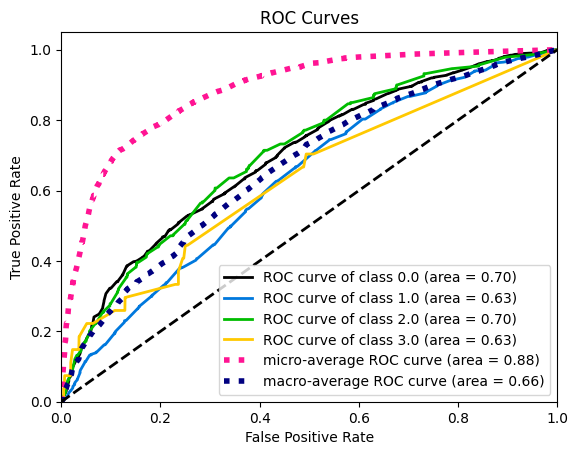

In [59]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

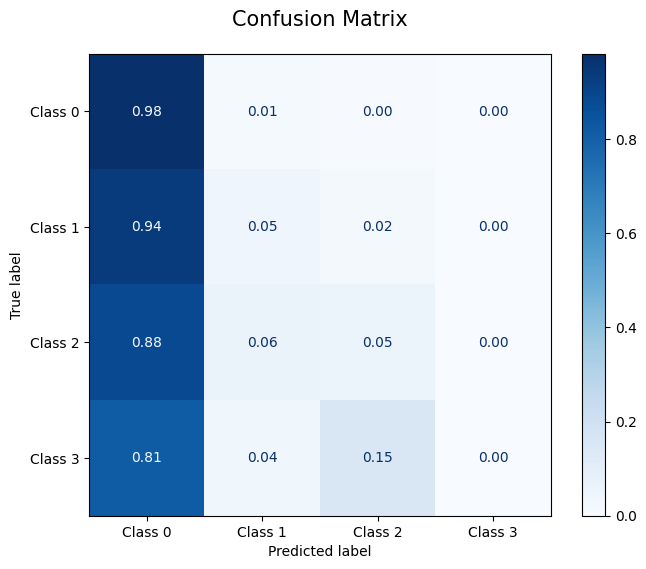

In [60]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

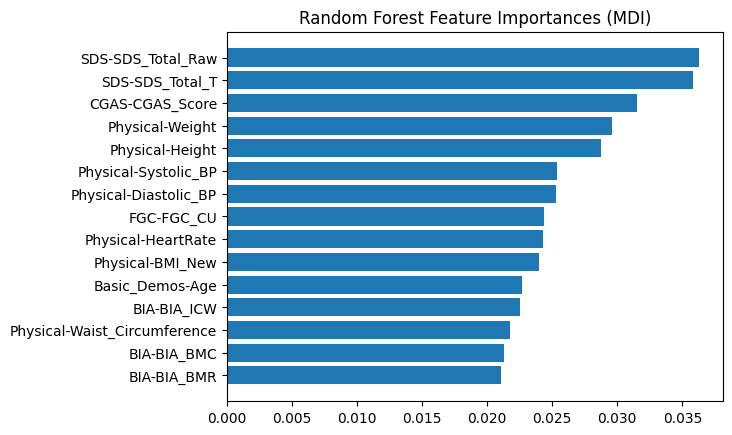

In [65]:
nbr_features = 15
tree_feature_importances = clf.feature_importances_
sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

y_ticks = np.arange(len(sorted_idx))
fig, ax = plt.subplots()
plt.barh(y_ticks, tree_feature_importances[sorted_idx])

if len(tree_feature_importances) == len(df.columns):
    feature_labels = df.columns[sorted_idx]
else:
    feature_labels = [f"feature_{i}" for i in sorted_idx]

plt.yticks(y_ticks, feature_labels)
plt.title("Random Forest Feature Importances (MDI)")
plt.show()

In [46]:
from sklearn.inspection import permutation_importance

In [66]:
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2)

C:\Users\steve\AppData\Local\Temp\ipykernel_39656\577352966.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False,


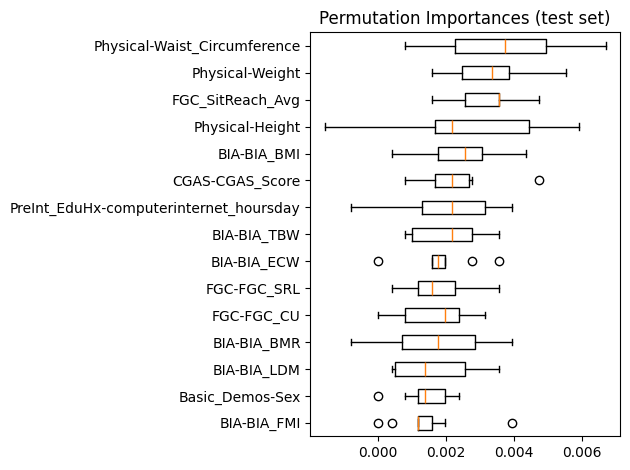

In [68]:
sorted_idx = result.importances_mean.argsort()[-nbr_features:]

fig, ax = plt.subplots()
plt.boxplot(result.importances[sorted_idx].T, vert=False,
            labels=np.array(df.columns)[sorted_idx])
plt.title("Permutation Importances (test set)")
plt.tight_layout()
plt.show()

In [49]:
from sklearn.tree import plot_tree

In [69]:
clf.estimators_[0]

,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",209652396
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number o

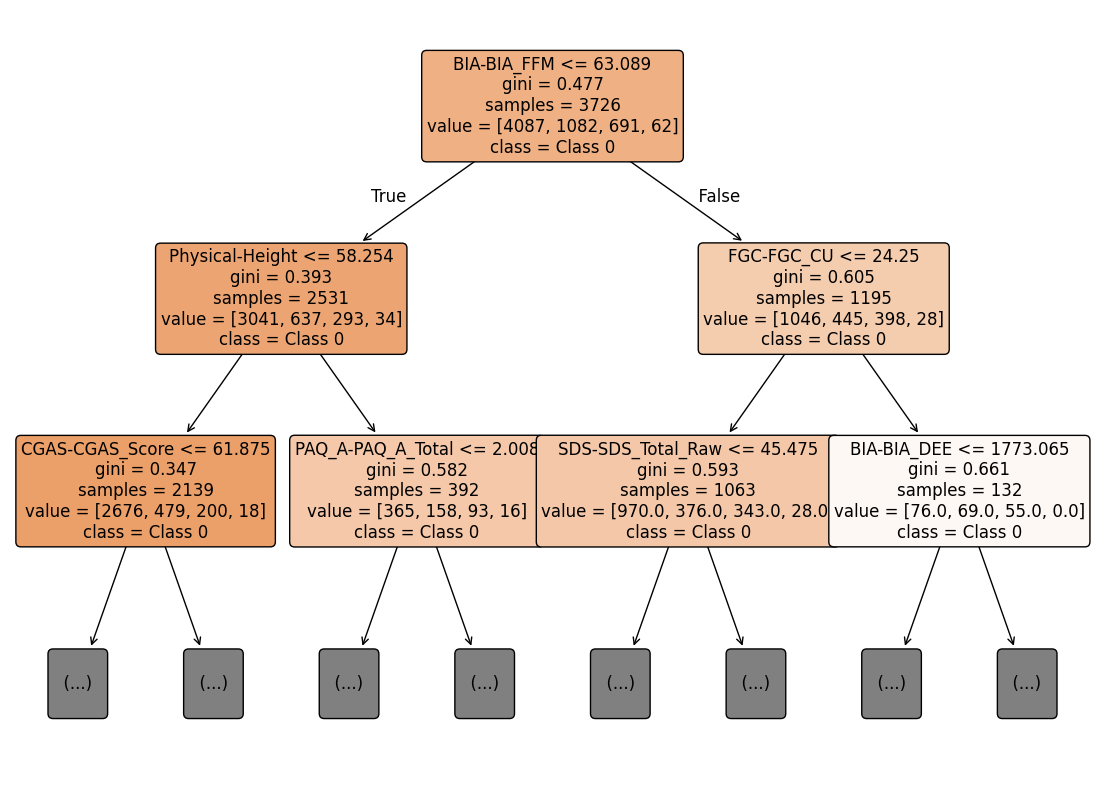

In [72]:
plt.figure(figsize=(14,10))
plot_tree(
    clf.estimators_[0],
    feature_names=df.columns,
    class_names=[f"Class {int(c)}" for c in clf.classes_],
    filled=True,
    rounded=True,
    fontsize=12,
    max_depth=2
)
plt.show()

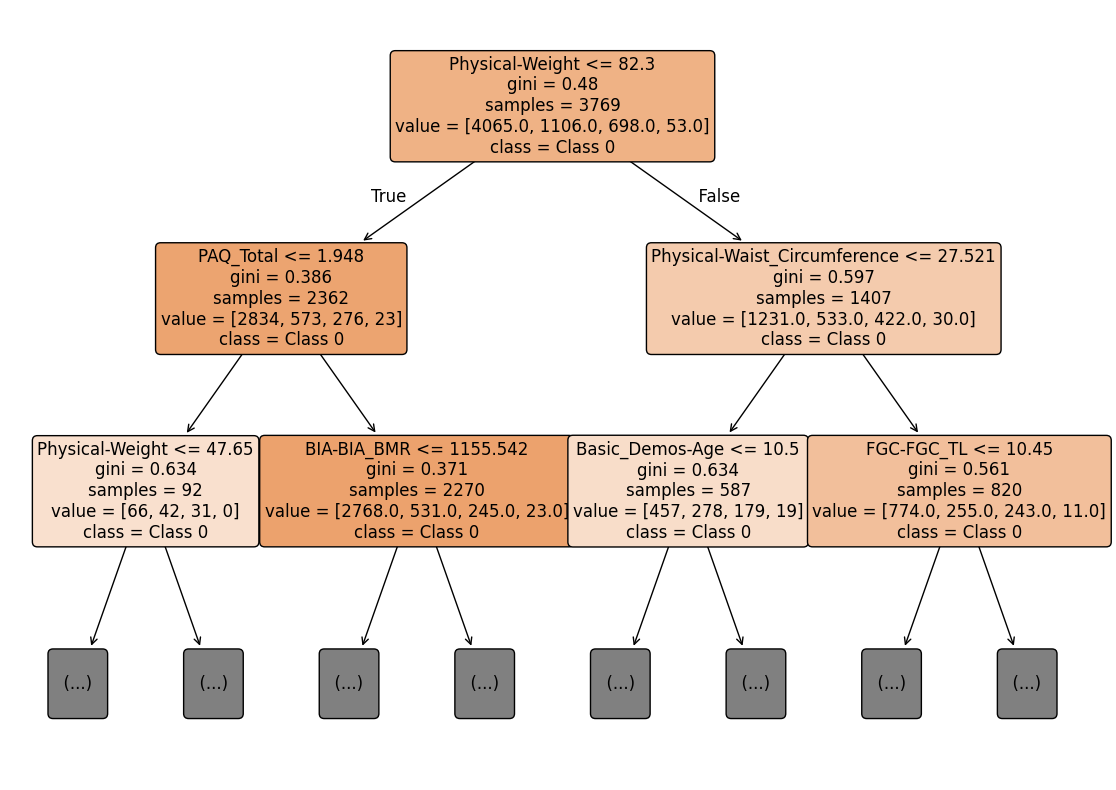

In [76]:
plt.figure(figsize=(14,10))
plot_tree(clf.estimators_[1], 
          feature_names=df.columns,
          class_names=[f"Class {int(c)}" for c in clf.classes_],
          filled=True, 
          rounded=True,
          fontsize=12,
          max_depth=2)  
plt.show()

In [44]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb

In [45]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 16336 samples
Distribution of classes after SMOTE : {0.0: 4084, 1.0: 4084, 2.0: 4084, 3.0: 4084}


In [47]:
# SelectFromModel with XGBoost

sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

# with smote it was 23 features selected, with random oversampling it is 33 features selected.

(16336, 17)

In [49]:
clf = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=None, min_samples_split=2, 
                             min_samples_leaf=1, 
                             min_weight_fraction_leaf=0.0, max_features=4, random_state=0)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6595744680851063
F1-score [0.80090158 0.12732919 0.16541353 0.05      ]
              precision    recall  f1-score   support

         0.0       0.71      0.91      0.80      1749
         1.0       0.25      0.09      0.13       482
         2.0       0.28      0.12      0.17       280
         3.0       0.08      0.04      0.05        27

    accuracy                           0.66      2538
   macro avg       0.33      0.29      0.29      2538
weighted avg       0.57      0.66      0.59      2538



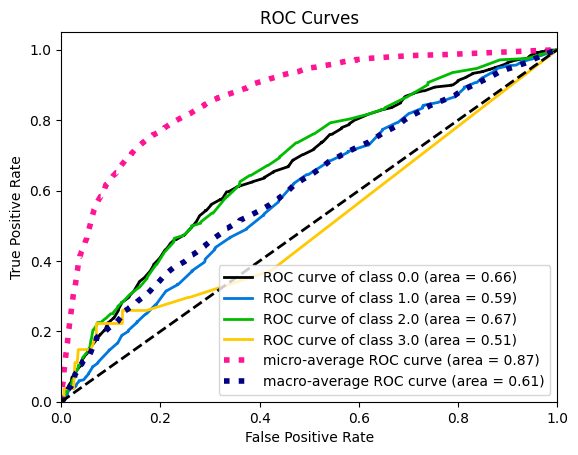

In [50]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

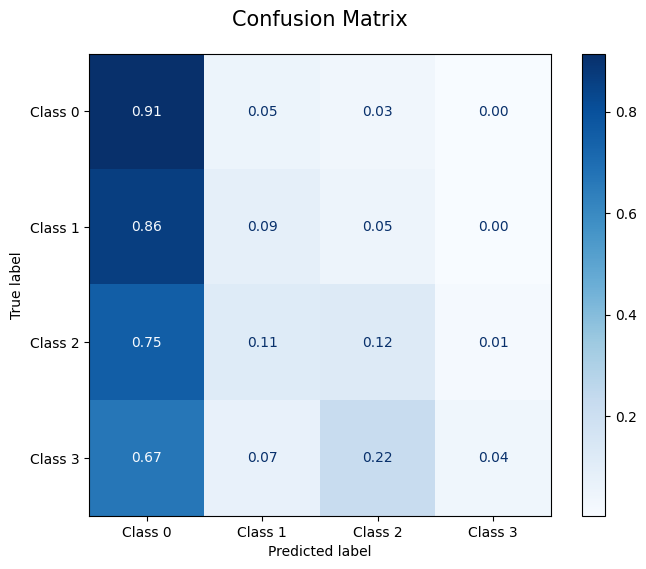

In [51]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [52]:
clf = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=None, min_samples_split=2, 
                             min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='log2', random_state=0)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6595744680851063
F1-score [0.80090158 0.12732919 0.16541353 0.05      ]
              precision    recall  f1-score   support

         0.0       0.71      0.91      0.80      1749
         1.0       0.25      0.09      0.13       482
         2.0       0.28      0.12      0.17       280
         3.0       0.08      0.04      0.05        27

    accuracy                           0.66      2538
   macro avg       0.33      0.29      0.29      2538
weighted avg       0.57      0.66      0.59      2538



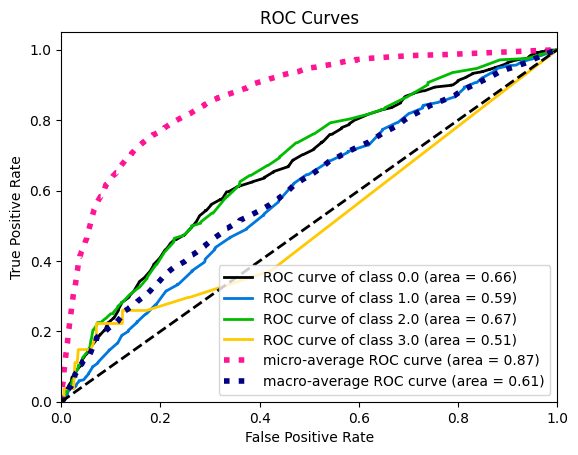

In [53]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

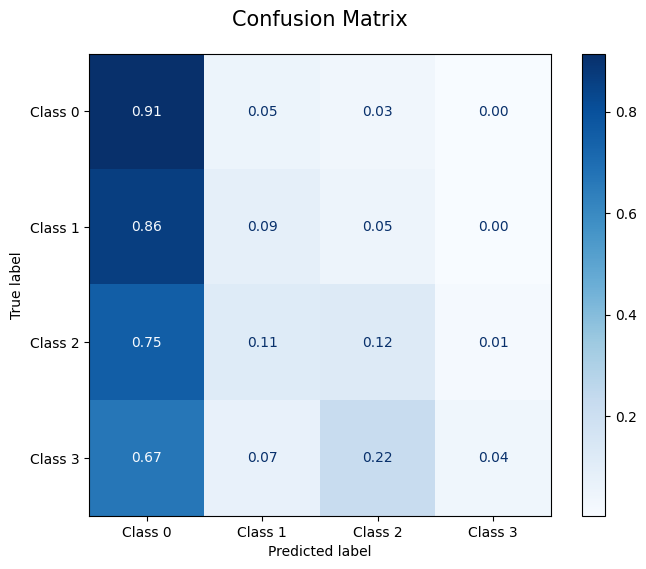

In [54]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [55]:
clf = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=4, min_samples_split=2, 
                             min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='log2', random_state=0)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5271867612293144
F1-score [0.71227965 0.15921788 0.23692308 0.0661157 ]
              precision    recall  f1-score   support

         0.0       0.75      0.68      0.71      1749
         1.0       0.24      0.12      0.16       482
         2.0       0.21      0.28      0.24       280
         3.0       0.04      0.44      0.07        27

    accuracy                           0.53      2538
   macro avg       0.31      0.38      0.29      2538
weighted avg       0.58      0.53      0.55      2538



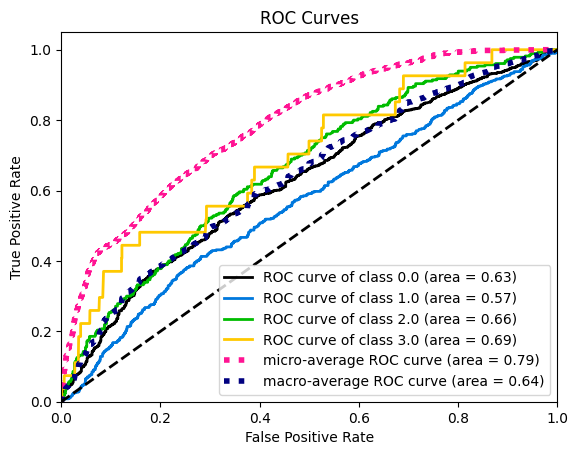

In [56]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

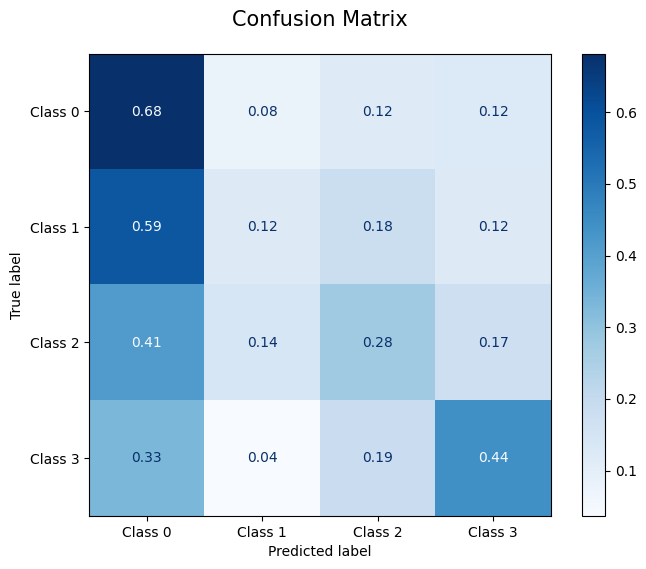

In [57]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

### Cross Validation

In [22]:
from sklearn.model_selection import cross_val_score

In [23]:
clf = RandomForestClassifier()
scores = cross_val_score(clf, X, y, cv=5)

print('Accuracy %.3f +/- %.3f' % (np.mean(scores), np.std(scores)))

Accuracy 0.689 +/- 0.002


### Tuning the hyper-parameters

In [15]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE
import xgboost as xgb

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectFromModel(
        xgb.XGBClassifier(
            n_estimators=100,
            random_state=42,
            eval_metric='logloss',
            use_label_encoder=False
        )
    )),
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    'clf__n_estimators':        [100, 200],
    'clf__max_features':        ['sqrt', 'log2'],
    'clf__min_samples_split':   [2, 5, 10, 20],
    'clf__min_samples_leaf':    [1, 5, 10, 20],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',     # macro = poids égal à chaque classe
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:56:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__max_features': ['sqrt', 'log2'], 'clf__min_samples_leaf': [1, 5, ...], 'clf__min_samples_split': [2, 5, ...], 'clf__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluatio

In [16]:
# Extract the Winning Parameters
print(f"Best Parameters found: {grid_search.best_params_}")

Best Parameters found: {'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 20, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}


In [17]:
# Grab the "Winning" model
best_model = grid_search.best_estimator_

# Make predictions on the unseen test data
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test) # Probabilities for AUC

# 3. The Evaluation Report
print("Final evaluation on test set")
print(f"Best internal CV Score: {grid_search.best_score_:.4f}")

print("\nDetailed Classification Report:")
# This shows Precision, Recall, and F1-Score 
print(classification_report(y_test, y_pred))

Final evaluation on test set
Best internal CV Score: 0.3779

Detailed Classification Report:
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.78      1749
         1.0       0.26      0.16      0.20       482
         2.0       0.25      0.29      0.27       280
         3.0       0.05      0.04      0.04        27

    accuracy                           0.62      2538
   macro avg       0.33      0.32      0.32      2538
weighted avg       0.59      0.62      0.60      2538



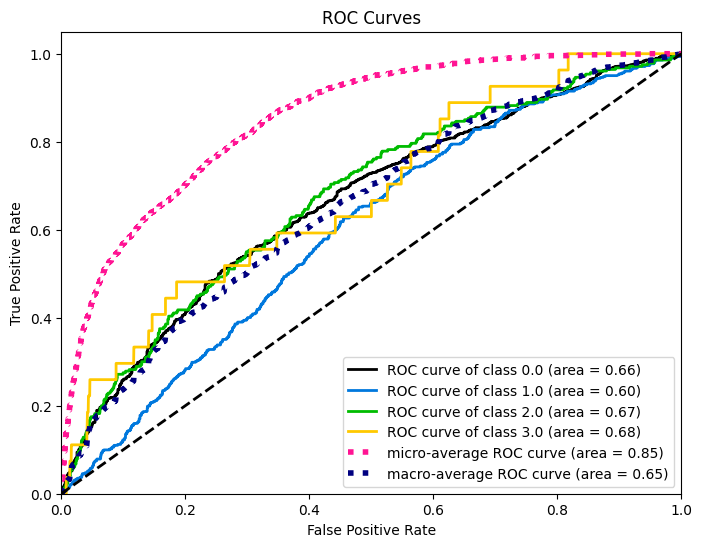

In [18]:
import scikitplot as skplt 

# 1. Get predictions from the BEST model found by GridSearch
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_score = best_model.predict_proba(X_test)

# ROC curve 
# Works for both 2 and 4 classes
skplt.metrics.plot_roc(y_test, y_score, figsize=(8, 6), title="ROC Curves")
plt.show()


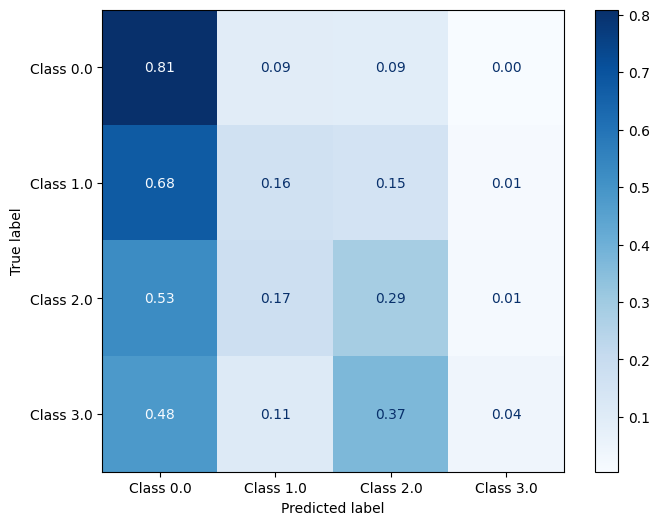

In [19]:
# Confusion Matrix
# Prepare labels dynamically based on current target
unique_classes = sorted(list(set(y_test)))
labels = [f"Class {i}" for i in unique_classes]

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Use 'normalize=true' to see percentages per row
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=labels, 
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f'
)

In [27]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE
import xgboost as xgb

pipeline = Pipeline([
    ('scaler',   StandardScaler()),
    ('smote',    SMOTE(random_state=42)),
    ('selector', SelectFromModel(
        xgb.XGBClassifier(
            n_estimators=100,
            random_state=42,
            eval_metric='logloss'
        )
    )),
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

param_dist = {
    'clf__n_estimators':      [100, 200, 300],
    'clf__max_depth':         [None] + list(np.arange(2, 20)),
    'clf__max_features':      ['sqrt', 'log2'],
    'clf__min_samples_split': [2, 5, 10, 20, 30, 50, 100],
    'clf__min_samples_leaf':  [1, 5, 10, 20, 30, 50, 100],
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=50,          # 10 trop faible pour 5 hyperparamètres
    cv=5,
    scoring='f1_macro', # macro = poids égal classes rares
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__max_depth': [None, 2, ...], 'clf__max_features': ['sqrt', 'log2'], 'clf__min_samples_leaf': [1, 5, ...], 'clf__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be s

In [28]:
# Print the best parameters found
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best internal CV Score: {random_search.best_score_:.4f}")

Best Parameters: {'clf__n_estimators': 200, 'clf__min_samples_split': 50, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 16}
Best internal CV Score: 0.3798


In [29]:
# Grab the "Winning" model
best_model = random_search.best_estimator_

# Make predictions on the unseen test data
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test) # Probabilities for AUC

# 3. The Evaluation Report
print("Final evaluation on test set")
print(f"Best internal CV Score: {random_search.best_score_:.4f}")

print("\nDetailed Classification Report:")
# This shows Precision, Recall, and F1-Score 
print(classification_report(y_test, y_pred))

Final evaluation on test set
Best internal CV Score: 0.3798

Detailed Classification Report:
              precision    recall  f1-score   support

         0.0       0.74      0.82      0.78      1749
         1.0       0.26      0.15      0.19       482
         2.0       0.24      0.25      0.25       280
         3.0       0.06      0.04      0.05        27

    accuracy                           0.62      2538
   macro avg       0.32      0.32      0.32      2538
weighted avg       0.58      0.62      0.60      2538



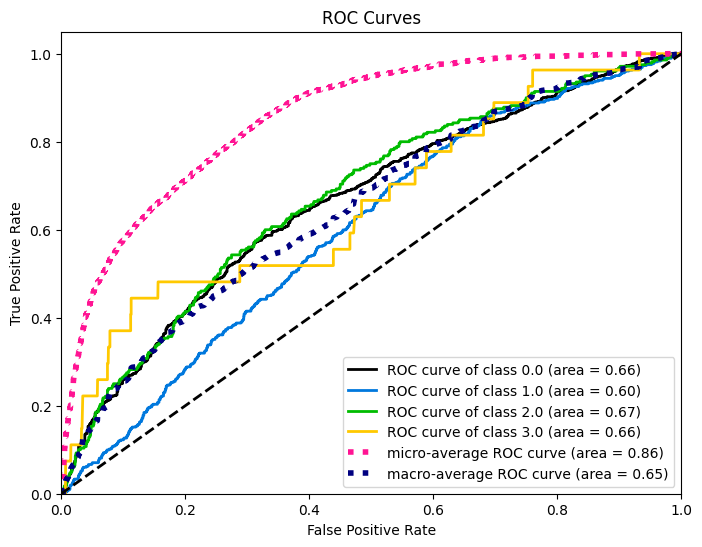

In [30]:
import scikitplot as skplt 

# 1. Get predictions from the BEST model found by GridSearch
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
y_score = best_model.predict_proba(X_test)

# ROC curve 
# Works for both 2 and 4 classes
skplt.metrics.plot_roc(y_test, y_score, figsize=(8, 6), title="ROC Curves")
plt.show()


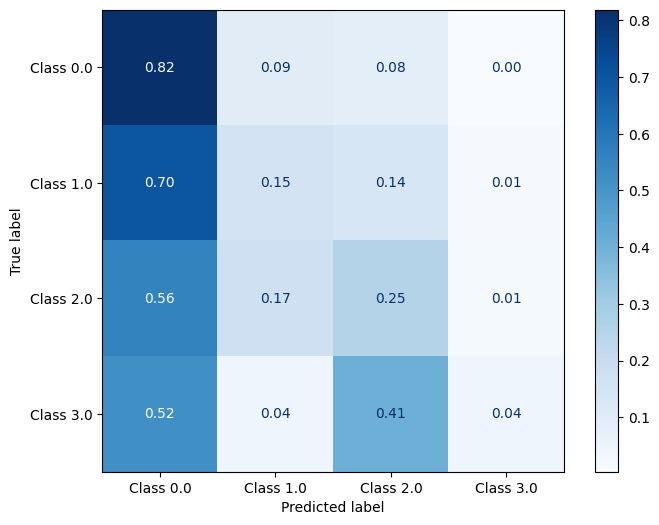

In [31]:
# Confusion Matrix
# Prepare labels dynamically based on current target
unique_classes = sorted(list(set(y_test)))
labels = [f"Class {i}" for i in unique_classes]

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Use 'normalize=true' to see percentages per row
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=labels, 
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f'
)

### Bagging

In [102]:
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier

If None, then the base estimator is a decision tree.

In [58]:
clf = BaggingClassifier(estimator=None, n_estimators=100, 
                        random_state=0)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.640661938534279
F1-score [0.78865979 0.16361072 0.16704289 0.04545455]
              precision    recall  f1-score   support

         0.0       0.72      0.87      0.79      1749
         1.0       0.26      0.12      0.16       482
         2.0       0.23      0.13      0.17       280
         3.0       0.06      0.04      0.05        27

    accuracy                           0.64      2538
   macro avg       0.31      0.29      0.29      2538
weighted avg       0.57      0.64      0.59      2538



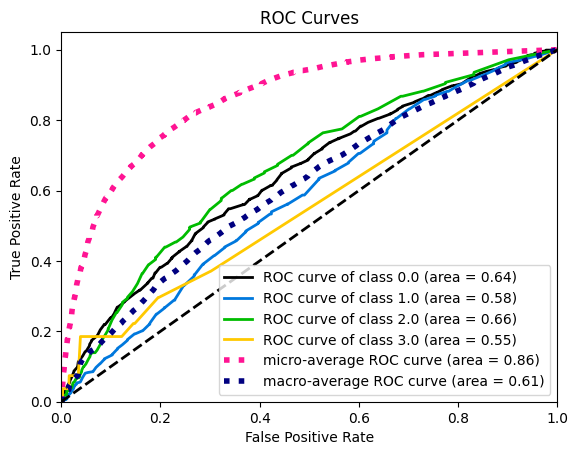

In [59]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

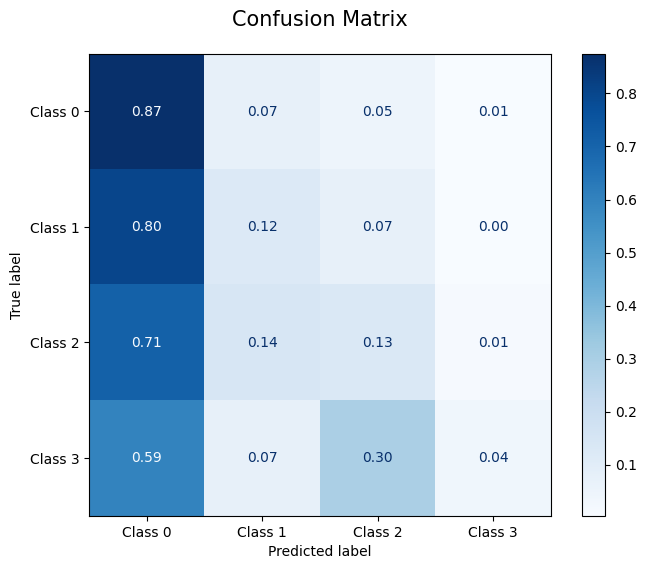

In [60]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [39]:
clf = BaggingClassifier(estimator=SVC(C=1000, class_weight='balanced'), 
                        n_estimators=10, random_state=0)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5791962174940898
F1-score [0.73969571 0.19101124 0.18007663 0.04081633]
              precision    recall  f1-score   support

         0.0       0.72      0.76      0.74      1749
         1.0       0.21      0.18      0.19       482
         2.0       0.19      0.17      0.18       280
         3.0       0.05      0.04      0.04        27

    accuracy                           0.58      2538
   macro avg       0.29      0.29      0.29      2538
weighted avg       0.56      0.58      0.57      2538



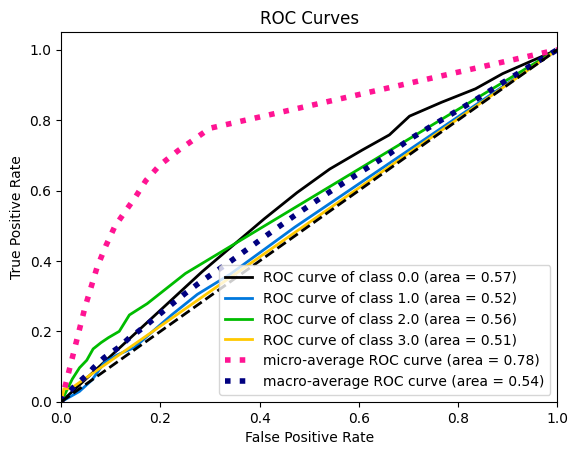

In [41]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

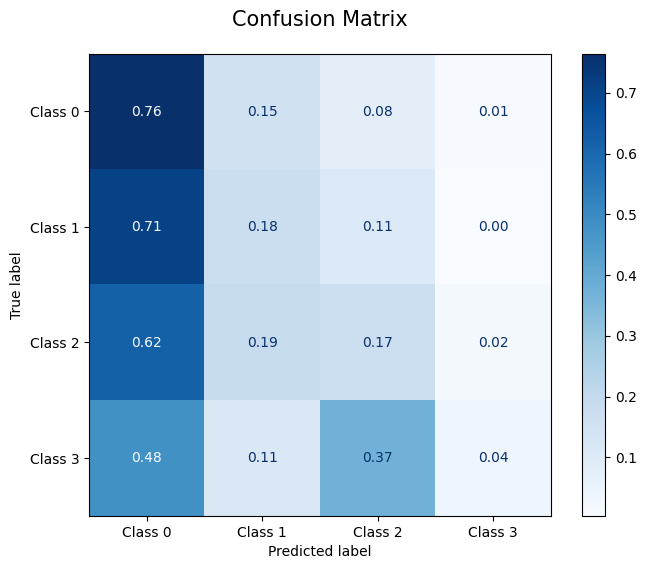

In [42]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [61]:
clf = BaggingClassifier(estimator=RandomForestClassifier(n_estimators=100, class_weight='balanced'), n_estimators=100, random_state=0)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6595744680851063
F1-score [0.80260195 0.1184     0.15496368 0.04878049]
              precision    recall  f1-score   support

         0.0       0.71      0.92      0.80      1749
         1.0       0.26      0.08      0.12       482
         2.0       0.24      0.11      0.15       280
         3.0       0.07      0.04      0.05        27

    accuracy                           0.66      2538
   macro avg       0.32      0.29      0.28      2538
weighted avg       0.57      0.66      0.59      2538



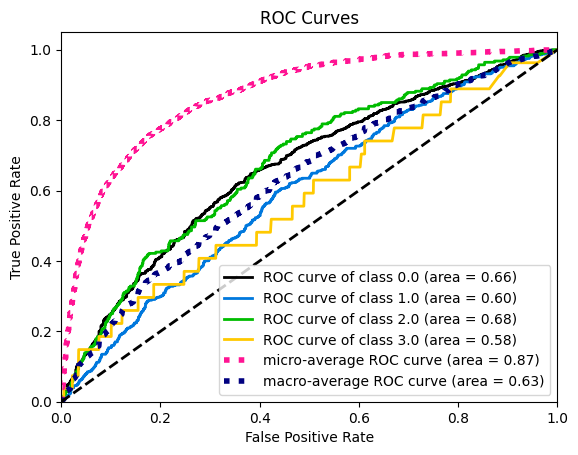

In [62]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

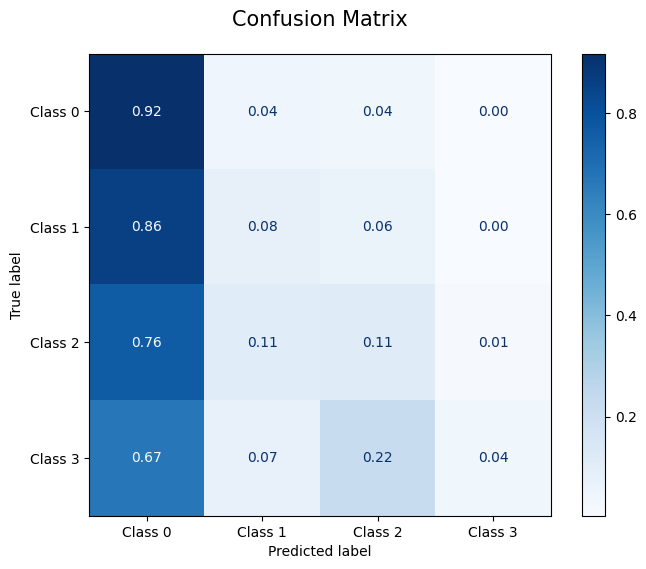

In [63]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

# Boosting

In [65]:
from sklearn.ensemble import AdaBoostClassifier

If None, then the base estimator is DecisionTreeClassifier(max_depth=1).

In [66]:
clf = AdaBoostClassifier(estimator=None, n_estimators=100, random_state=0)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5508274231678487
F1-score [0.73051481 0.17771883 0.19097222 0.04460967]
              precision    recall  f1-score   support

         0.0       0.73      0.73      0.73      1749
         1.0       0.25      0.14      0.18       482
         2.0       0.19      0.20      0.19       280
         3.0       0.02      0.22      0.04        27

    accuracy                           0.55      2538
   macro avg       0.30      0.32      0.29      2538
weighted avg       0.57      0.55      0.56      2538



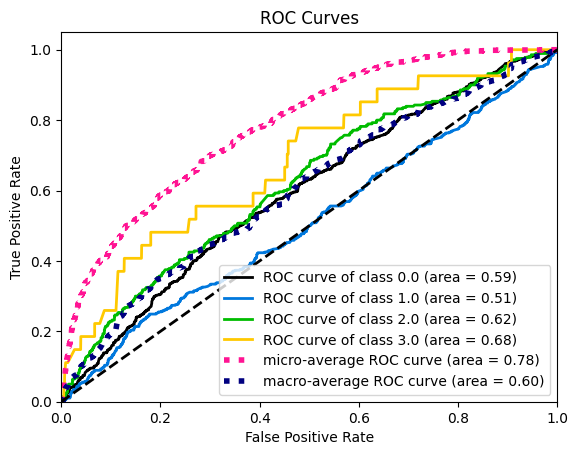

In [67]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

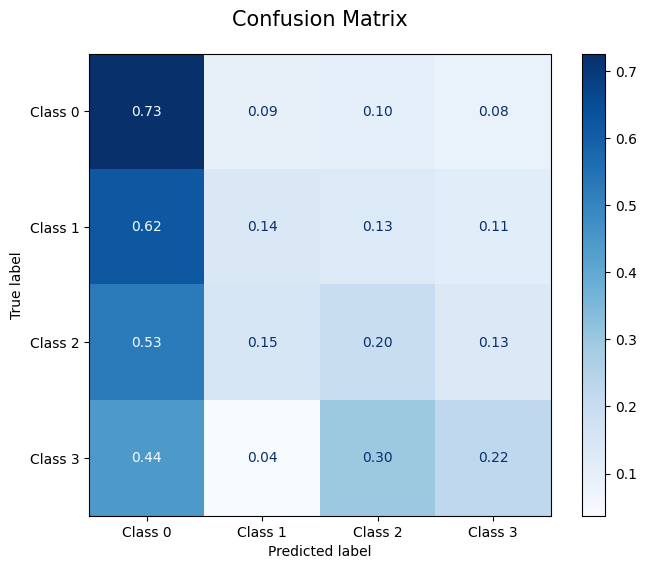

In [68]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [69]:
clf = AdaBoostClassifier(estimator=RandomForestClassifier(n_estimators=100), n_estimators=100, random_state=0)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6548463356973995
F1-score [0.79869149 0.14045802 0.14009662 0.        ]
              precision    recall  f1-score   support

         0.0       0.71      0.91      0.80      1749
         1.0       0.27      0.10      0.14       482
         2.0       0.22      0.10      0.14       280
         3.0       0.00      0.00      0.00        27

    accuracy                           0.65      2538
   macro avg       0.30      0.28      0.27      2538
weighted avg       0.57      0.65      0.59      2538



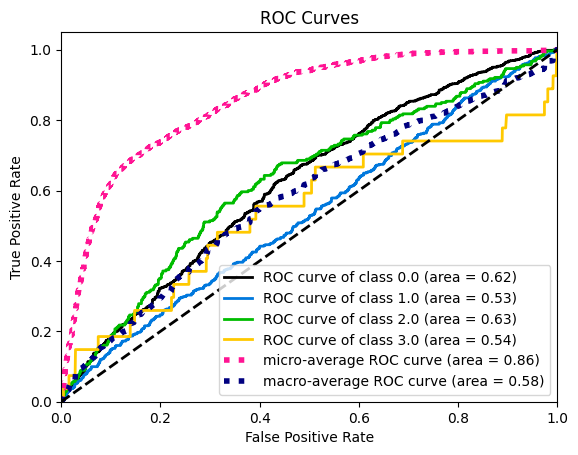

In [70]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

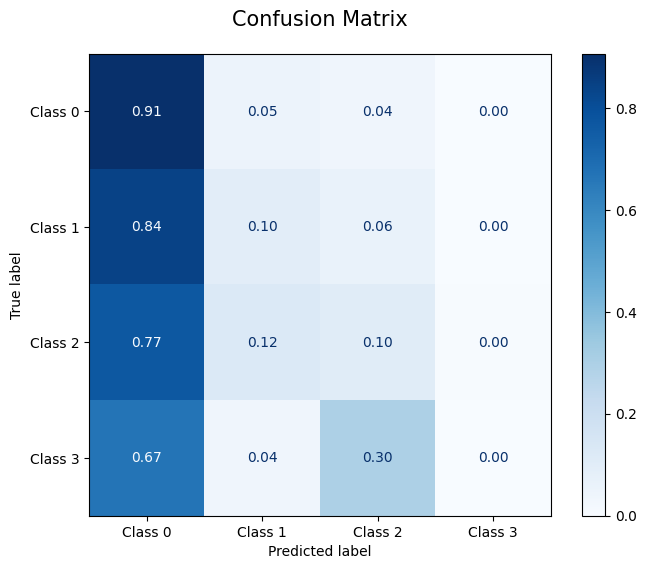

In [71]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

# New target variable

### Basic_Demos-Enroll_Season

In [171]:
df['sii']=df_original.loc[df.index, 'sii']
df.head()

,Basic_Demos-Age,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,...,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii,Basic_Demos-Enroll_Season
0,5.0,3,51.00,0,46.000,50.8,26.0,73.9,85.6,114.00,...,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0,2.0,0
1,9.0,1,62.55,0,48.000,46.0,22.0,75.0,70.0,122.00,...,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0,0.0,2
2,10.0,0,71.00,0,56.500,75.6,25.4,65.0,94.0,117.00,...,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0,0.0,2
3,9.0,0,71.00,2,56.000,81.6,26.0,60.0,97.0,117.00,...,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0,1.0,3
4,18.0,2,65.00,1,55.003,77.0,26.0,68.0,77.9,112.35,...,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0,0.0,1


In [173]:
df_random_f = df.copy()

In [174]:
df.drop(columns=['Basic_Demos-Enroll_Season'], inplace=True)

In [175]:
X = df.values
y = np.array(df_random_f['Basic_Demos-Enroll_Season'])

In [176]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [124]:
clf = RandomForestClassifier(n_estimators=100, 
                             criterion='gini', 
                             max_depth=None, 
                             min_samples_split=2, 
                             min_samples_leaf=1, 
                             min_weight_fraction_leaf=0.0, 
                             max_features='sqrt', 
                             random_state=0, 
                             n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.8230890464933018
F1-score [0.82876064 0.81212121 0.82108902 0.83224401]
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       537
           1       0.80      0.82      0.81       734
           2       0.80      0.85      0.82       562
           3       0.85      0.81      0.83       705

    accuracy                           0.82      2538
   macro avg       0.82      0.82      0.82      2538
weighted avg       0.82      0.82      0.82      2538



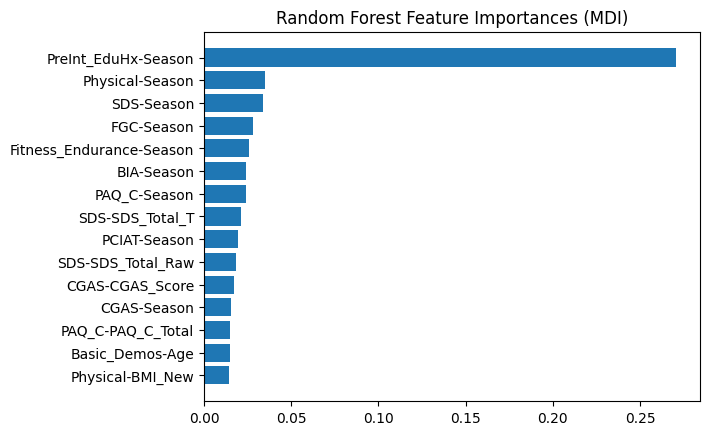

In [126]:
nbr_features = 15

tree_feature_importances = clf.feature_importances_
sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

y_ticks = np.arange(0, len(sorted_idx))
fig, ax = plt.subplots()
plt.barh(y_ticks, tree_feature_importances[sorted_idx])
plt.yticks(y_ticks, df.columns[sorted_idx])
plt.title("Random Forest Feature Importances (MDI)")
plt.show()

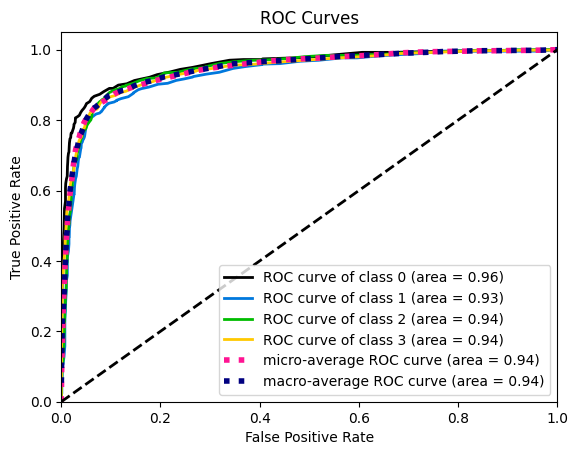

In [127]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

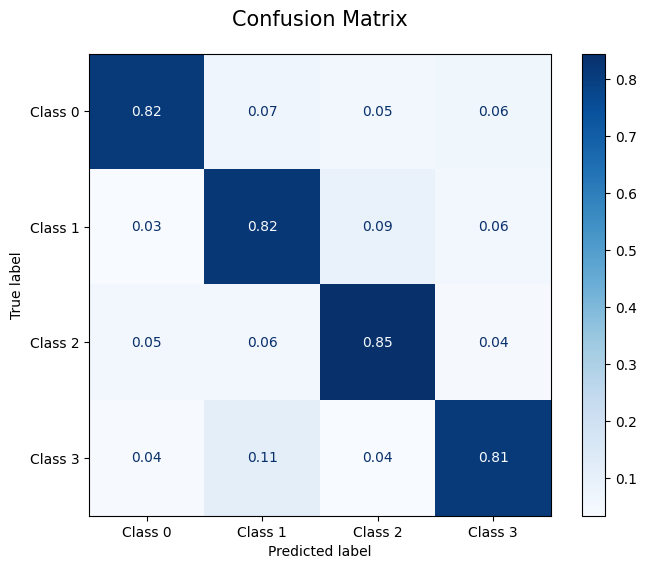

In [128]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

**Bagging**

In [23]:
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier

If None, then the base estimator is a decision tree.

In [129]:
clf = BaggingClassifier(estimator=None, n_estimators=100, 
                        random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.830575256107171
F1-score [0.84160305 0.82805125 0.82322801 0.83114993]
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       537
           1       0.82      0.84      0.83       734
           2       0.79      0.86      0.82       562
           3       0.85      0.81      0.83       705

    accuracy                           0.83      2538
   macro avg       0.83      0.83      0.83      2538
weighted avg       0.83      0.83      0.83      2538



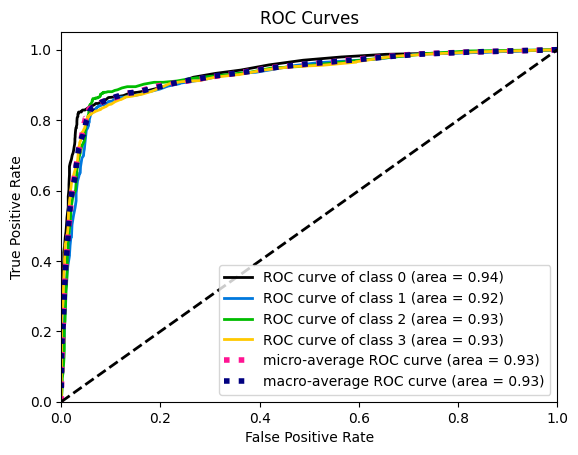

In [130]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

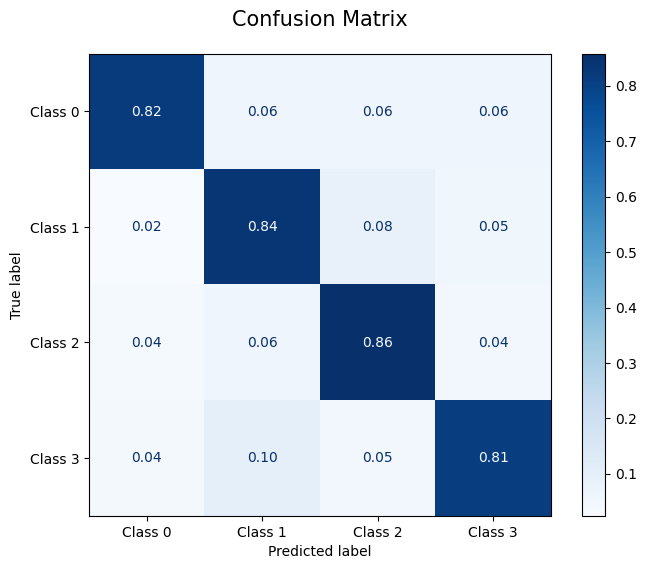

In [131]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [177]:
# Bagging con SVC depend of distances i have to normalize the data before using it in bagging classifier.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [178]:
clf = BaggingClassifier(estimator=SVC(C=1000), 
                        n_estimators=10, random_state=0)

clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6725768321513003
F1-score [0.70320405 0.67195767 0.56818182 0.72919818]
              precision    recall  f1-score   support

           0       0.64      0.78      0.70       537
           1       0.65      0.69      0.67       734
           2       0.61      0.53      0.57       562
           3       0.78      0.68      0.73       705

    accuracy                           0.67      2538
   macro avg       0.67      0.67      0.67      2538
weighted avg       0.68      0.67      0.67      2538



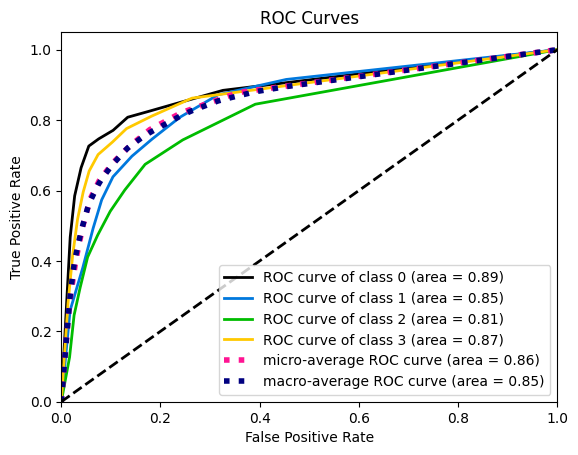

In [179]:
y_score = clf.predict_proba(X_test_scaled)
plot_roc(y_test, y_score)
plt.show()

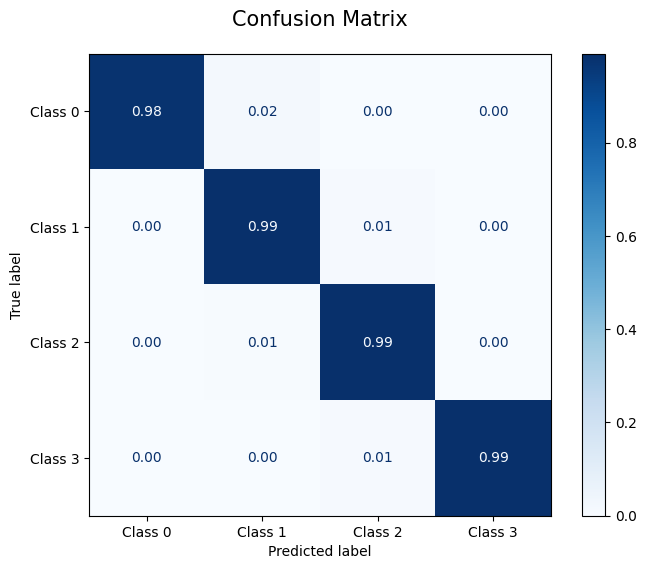

In [135]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [136]:
clf = BaggingClassifier(estimator=RandomForestClassifier(n_estimators=100), n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.8266351457840819
F1-score [0.83981043 0.81793478 0.81475129 0.83586406]
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       537
           1       0.82      0.82      0.82       734
           2       0.79      0.85      0.81       562
           3       0.85      0.82      0.84       705

    accuracy                           0.83      2538
   macro avg       0.83      0.83      0.83      2538
weighted avg       0.83      0.83      0.83      2538



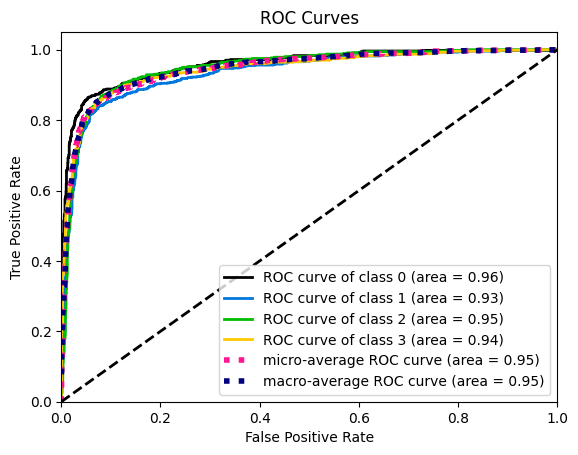

In [137]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

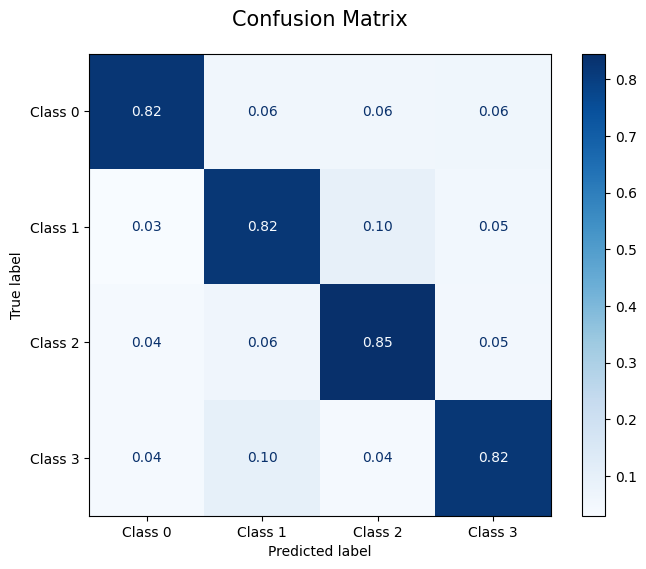

In [138]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

**Boosting**

In [35]:
from sklearn.ensemble import AdaBoostClassifier

If None, then the base estimator is DecisionTreeClassifier(max_depth=1).

In [139]:
clf = AdaBoostClassifier(estimator=None, n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.8211189913317573
F1-score [0.84270734 0.81351527 0.79822222 0.83198826]
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       537
           1       0.78      0.85      0.81       734
           2       0.80      0.80      0.80       562
           3       0.86      0.80      0.83       705

    accuracy                           0.82      2538
   macro avg       0.83      0.82      0.82      2538
weighted avg       0.82      0.82      0.82      2538



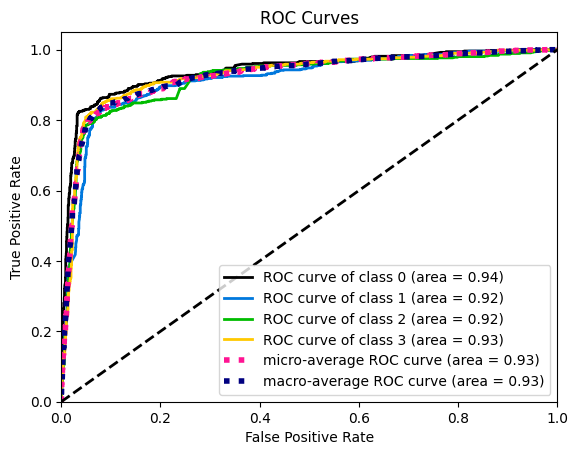

In [140]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

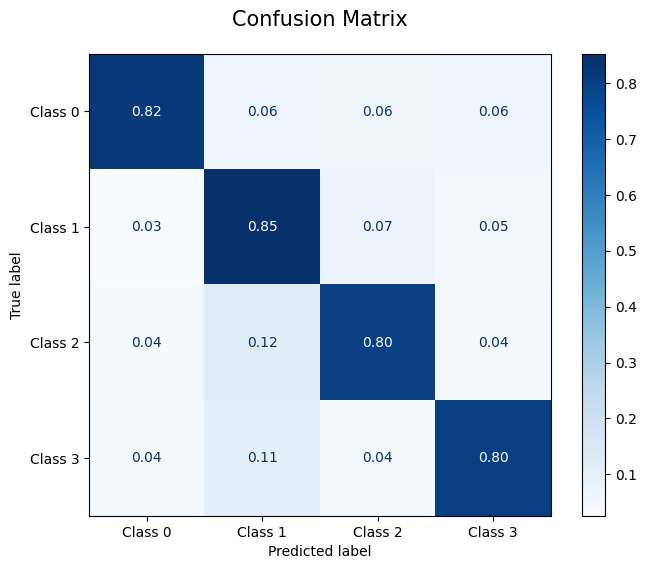

In [141]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [142]:
clf = AdaBoostClassifier(estimator=RandomForestClassifier(n_estimators=100), n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.8191489361702128
F1-score [0.82739212 0.82002706 0.79896462 0.82884195]
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       537
           1       0.81      0.83      0.82       734
           2       0.78      0.82      0.80       562
           3       0.85      0.81      0.83       705

    accuracy                           0.82      2538
   macro avg       0.82      0.82      0.82      2538
weighted avg       0.82      0.82      0.82      2538



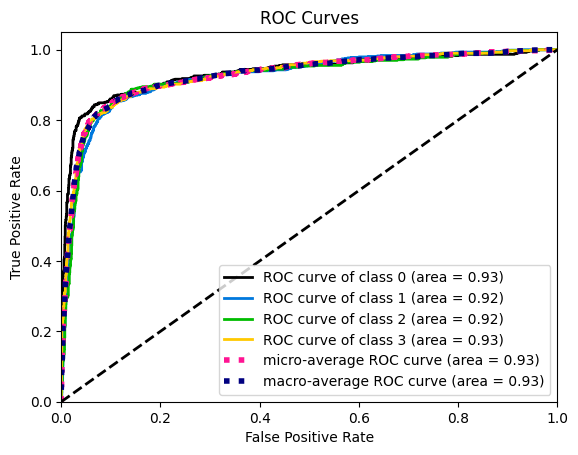

In [143]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

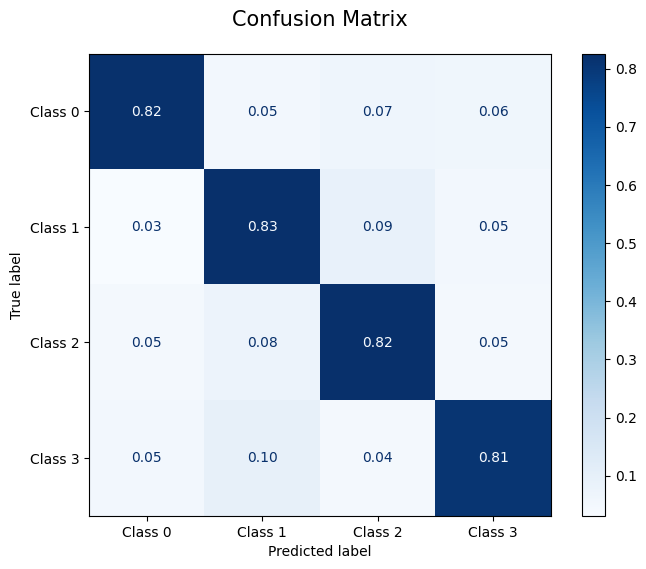

In [144]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

### Basic_Demos-Sex

In [145]:
df["Basic_Demos-Enroll_Season"] = df_random_f["Basic_Demos-Enroll_Season"]
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,...,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii,Basic_Demos-Enroll_Season
0,5.0,0.0,3,51.00,0,46.000,50.8,26.0,73.9,85.6,...,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0,2.0,0
1,9.0,0.0,1,62.55,0,48.000,46.0,22.0,75.0,70.0,...,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0,0.0,2
2,10.0,1.0,0,71.00,0,56.500,75.6,25.4,65.0,94.0,...,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0,0.0,2
3,9.0,0.0,0,71.00,2,56.000,81.6,26.0,60.0,97.0,...,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0,1.0,3
4,18.0,1.0,2,65.00,1,55.003,77.0,26.0,68.0,77.9,...,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0,0.0,1


In [146]:
df_random_f2 = df.copy()

In [147]:
df.drop(columns=['Basic_Demos-Sex'], inplace=True)

In [148]:
X = df.values
y = np.array(df_random_f2['Basic_Demos-Sex'])

In [149]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [150]:
clf = RandomForestClassifier(n_estimators=100, 
                             criterion='gini', 
                             max_depth=None, 
                             min_samples_split=2, 
                             min_samples_leaf=1, 
                             min_weight_fraction_leaf=0.0, 
                             max_features='sqrt', 
                             random_state=0, 
                             n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.7454688731284476
F1-score [0.8031688  0.63991081]
              precision    recall  f1-score   support

         0.0       0.75      0.87      0.80      1516
         1.0       0.74      0.56      0.64      1022

    accuracy                           0.75      2538
   macro avg       0.74      0.72      0.72      2538
weighted avg       0.75      0.75      0.74      2538



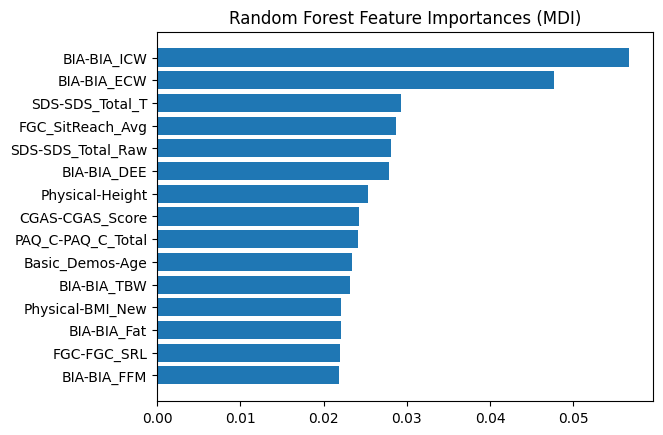

In [151]:
nbr_features = 15

tree_feature_importances = clf.feature_importances_
sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

y_ticks = np.arange(0, len(sorted_idx))
fig, ax = plt.subplots()
plt.barh(y_ticks, tree_feature_importances[sorted_idx])
plt.yticks(y_ticks, df.columns[sorted_idx])
plt.title("Random Forest Feature Importances (MDI)")
plt.show()

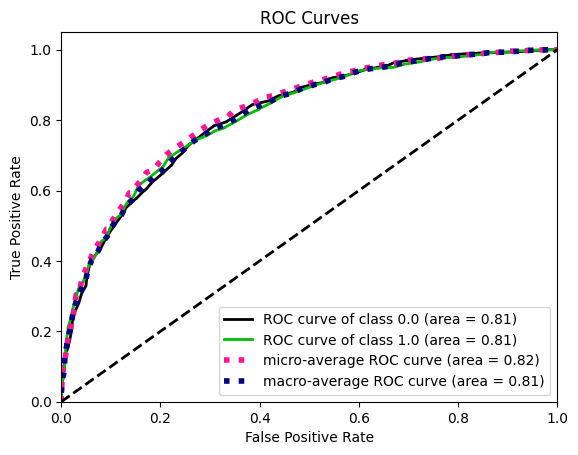

In [152]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

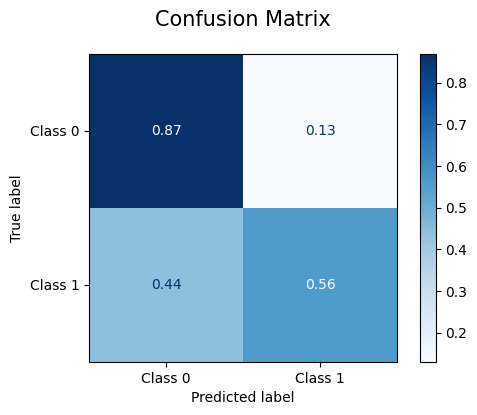

In [153]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(6, 4))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

**Bagging**

In [50]:
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier

If None, then the base estimator is a decision tree.

In [154]:
clf = BaggingClassifier(estimator=None, n_estimators=100, 
                        random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.760441292356186
F1-score [0.8091651  0.67830688]
              precision    recall  f1-score   support

         0.0       0.77      0.85      0.81      1516
         1.0       0.74      0.63      0.68      1022

    accuracy                           0.76      2538
   macro avg       0.76      0.74      0.74      2538
weighted avg       0.76      0.76      0.76      2538



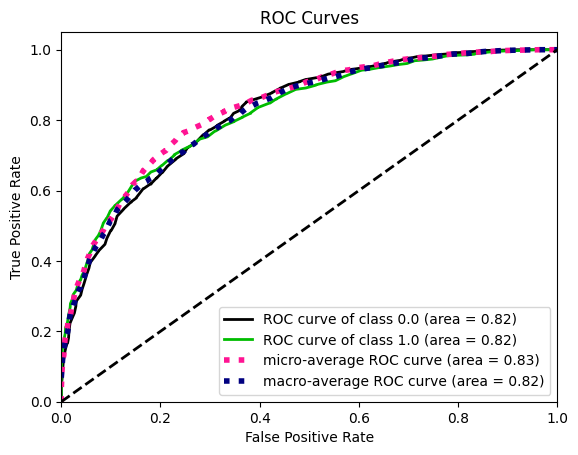

In [155]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

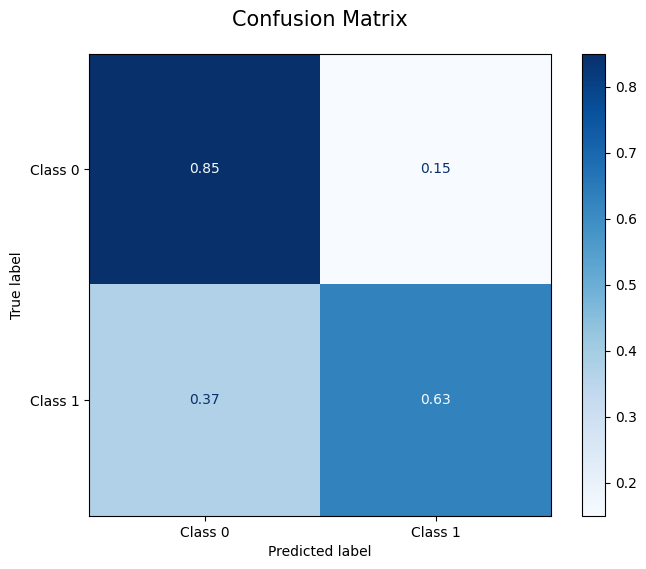

In [156]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [158]:
# Bagging con SVC depend of distances i have to normalize the data before using it in bagging classifier.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [159]:
clf = BaggingClassifier(estimator=SVC(C=1000), 
                        n_estimators=10, random_state=0)

clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6812450748620962
F1-score [0.74194577 0.58320453]
              precision    recall  f1-score   support

         0.0       0.72      0.77      0.74      1516
         1.0       0.62      0.55      0.58      1022

    accuracy                           0.68      2538
   macro avg       0.67      0.66      0.66      2538
weighted avg       0.68      0.68      0.68      2538



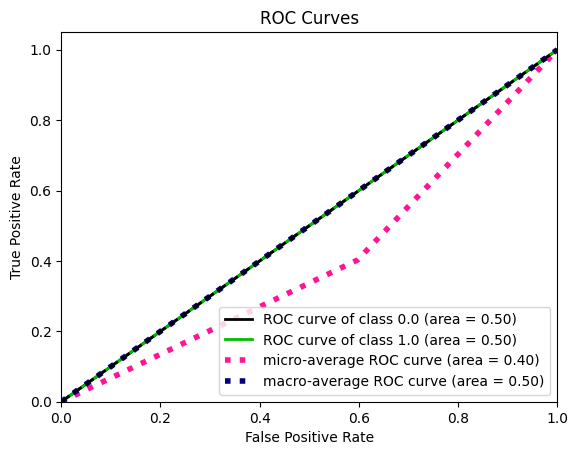

In [160]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

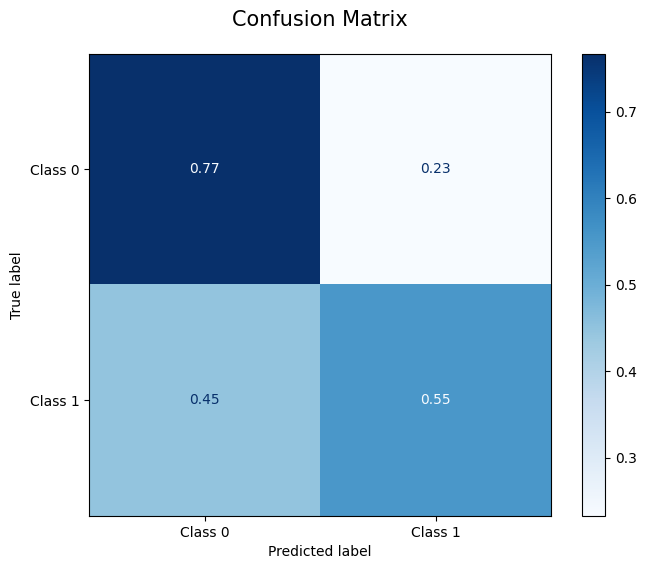

In [161]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [162]:
clf = BaggingClassifier(estimator=RandomForestClassifier(n_estimators=100), n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.7423167848699763
F1-score [0.80241692 0.62967157]
              precision    recall  f1-score   support

         0.0       0.74      0.88      0.80      1516
         1.0       0.75      0.54      0.63      1022

    accuracy                           0.74      2538
   macro avg       0.74      0.71      0.72      2538
weighted avg       0.74      0.74      0.73      2538



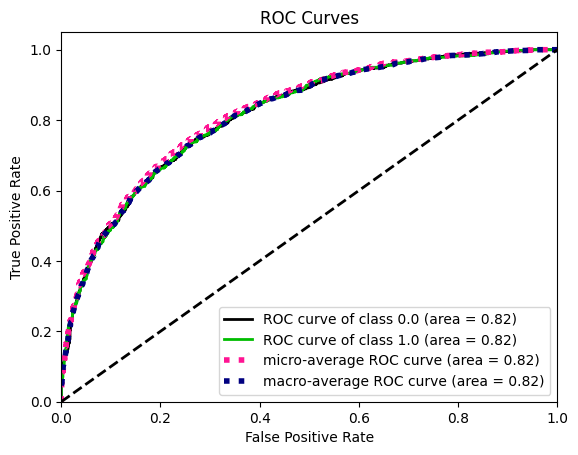

In [163]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

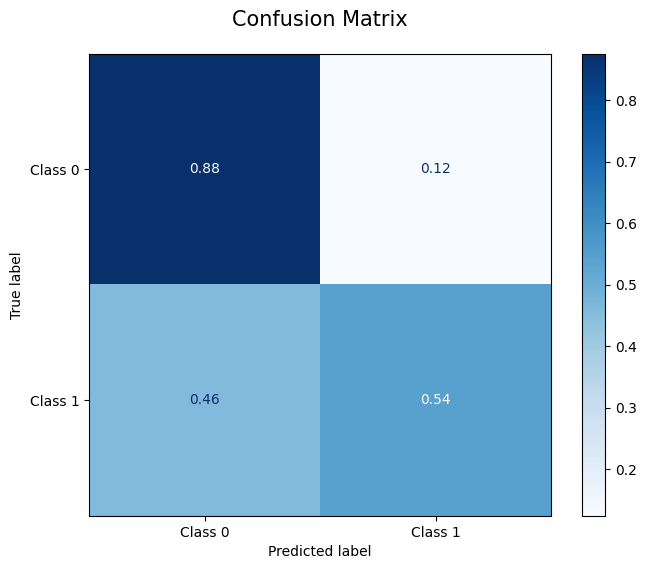

In [164]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

**Boosting**

In [61]:
from sklearn.ensemble import AdaBoostClassifier

If None, then the base estimator is DecisionTreeClassifier(max_depth=1).

In [165]:
clf = AdaBoostClassifier(estimator=None, n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.7159180457052797
F1-score [0.78419635 0.58443804]
              precision    recall  f1-score   support

         0.0       0.72      0.86      0.78      1516
         1.0       0.71      0.50      0.58      1022

    accuracy                           0.72      2538
   macro avg       0.71      0.68      0.68      2538
weighted avg       0.72      0.72      0.70      2538



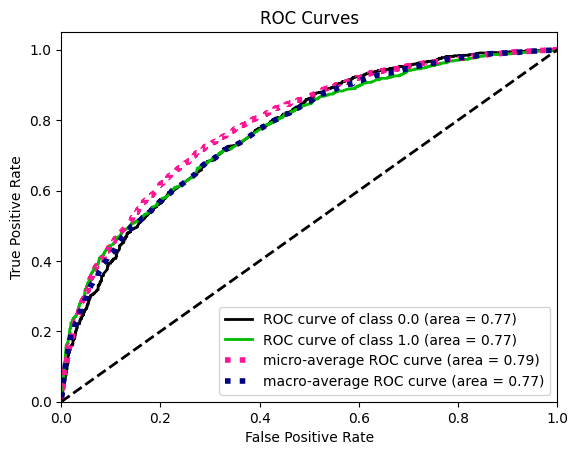

In [166]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

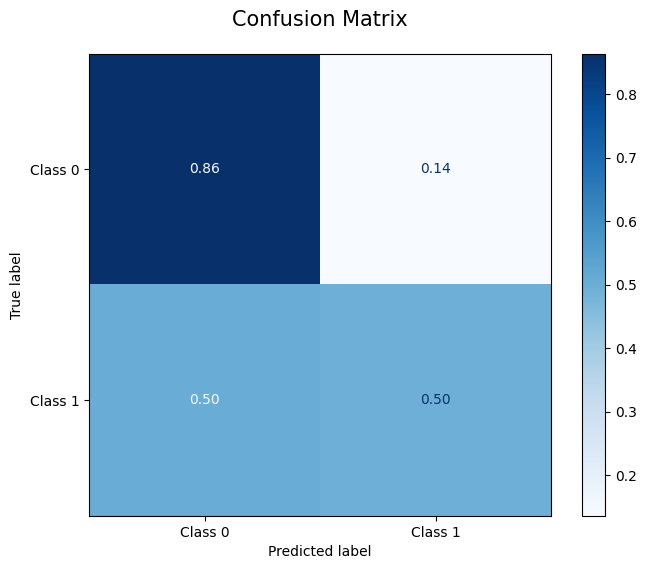

In [167]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [168]:
clf = AdaBoostClassifier(estimator=RandomForestClassifier(n_estimators=100), n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.7364066193853428
F1-score [0.79891794 0.61749571]
              precision    recall  f1-score   support

         0.0       0.73      0.88      0.80      1516
         1.0       0.74      0.53      0.62      1022

    accuracy                           0.74      2538
   macro avg       0.74      0.70      0.71      2538
weighted avg       0.74      0.74      0.73      2538



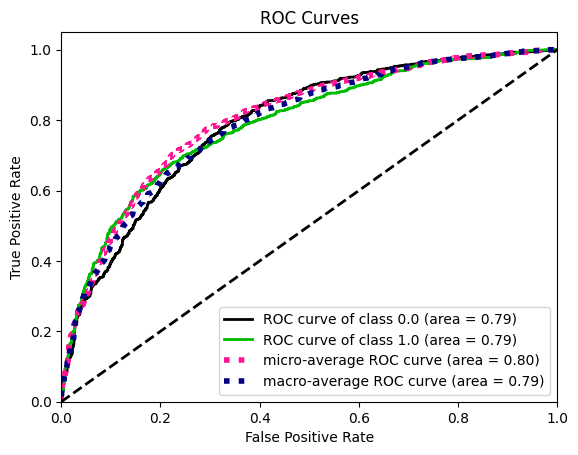

In [169]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

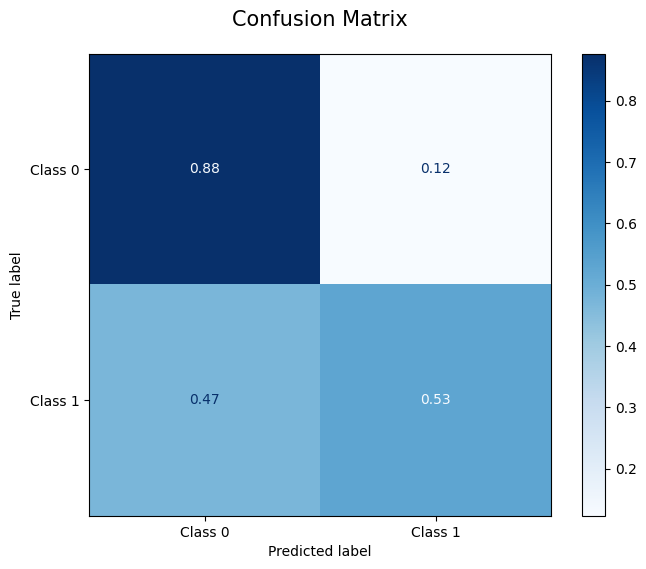

In [170]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()